# 20.9 回答出現正確名詞，就算看懂照片了嗎？


圖裡有人和腳踏車，卻可能在騎車，也可能站在車旁。兩個正確名詞還不能回答「人在做什麼」。照片問答要依請求核對物件、動作或關係，再查回答多出的細節是否有畫面支持。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

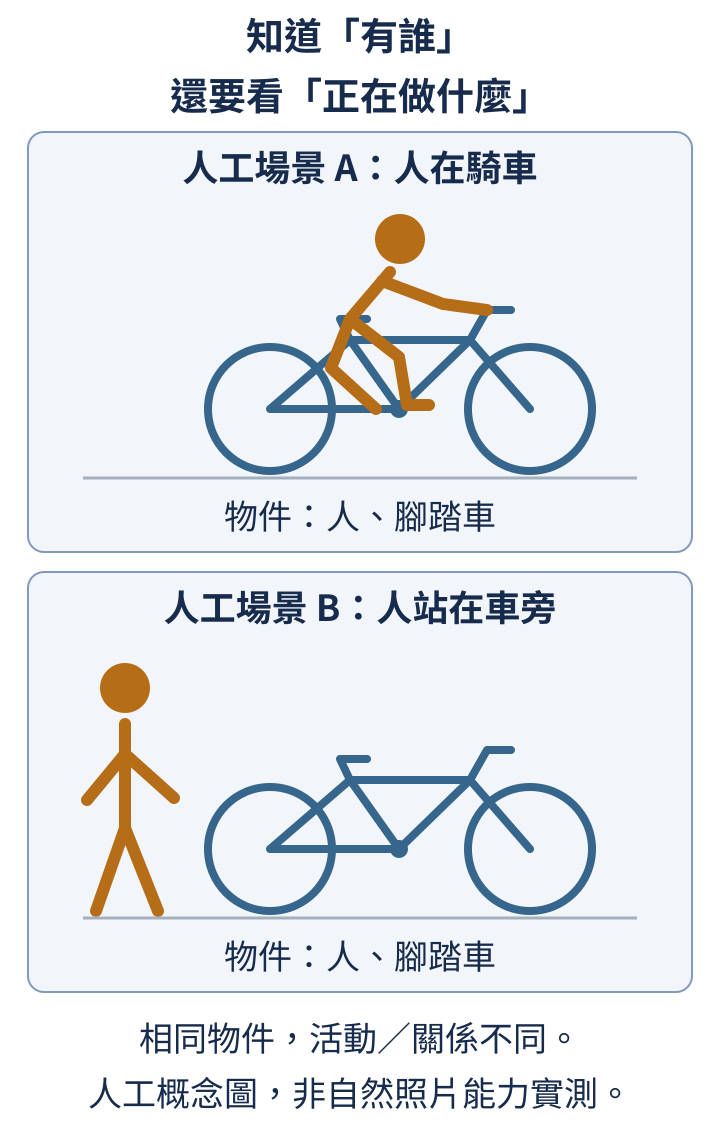

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/natural_photo_evidence.svg")))

In [3]:
truth = {"objects": {"人", "腳踏車"}, "activity": "騎車"}
cards = [
    {"objects": {"人", "腳踏車"}, "activity": "騎車"},
    {"objects": {"人", "腳踏車"}, "activity": "站在車旁"},
]
for index, card in enumerate(cards):
    print("卡", index, "物件吻合", card["objects"] == truth["objects"])
    print("活動符合本題", card["activity"] == truth["activity"])

卡 0 物件吻合 True
活動符合本題 True
卡 1 物件吻合 True
活動符合本題 False


兩張人工回答卡的物件集合都吻合，只有第一張的活動符合「騎車」。程式沒有讀圖，只隔離評分差別。真正描述允許同義措辭，但不能把站在車旁當騎車。

[20.4的兩隻貓訓練照片](https://birdhackor.github.io/tiny-perceptron-vlm/20.4.html)若問數量，答「兩隻」就完成；問左貓姿勢，則核對抬前腳。再補「牠等主人回家」是可見內容以外的推測，長一些不代表更完整。保持問題、歷史與設定，換實際圖片，答案也應依新畫面重核；少量換圖只支持該組對照；還要用未參與本課訓練與選版的照片，分別檢查描述、可見事實問答等用途。照片家族怎樣一起留出，見[20.5](https://birdhackor.github.io/tiny-perceptron-vlm/20.5.html)。
